# AML23703 – Quantum Computing

# Tutorial 4: Multi-Qubit Gates and Circuit Composition

### Name: LAASYA S D

### USN: 1GA23AI021

### Department: Artificial Intelligence and Machine Learning

### Semester: VII

### Course Code: AML23703

### Date: 12-08-2026

# Objective

The objective of this tutorial is to understand multi-qubit quantum gates such as CNOT, CZ and Toffoli gates, construct multi-qubit circuits, study entanglement generation, and use Qiskit for circuit composition and visualization.

# Theory

Multi-qubit gates operate on two or more qubits. A controlled gate uses one qubit as the control and another as the target. The CNOT gate flips the target qubit only when the control qubit is in state |1⟩. Multi-qubit gates are important for creating entanglement and implementing quantum algorithms.

# Exercise 1 (Easy)

## Question

Implement a CNOT gate circuit with the control qubit in state |1⟩ and verify that the target qubit flips.

Final Statevector:
Statevector([0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],
            dims=(2, 2))


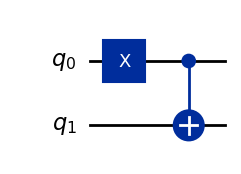

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from IPython.display import display

# Create a 2-qubit circuit
qc = QuantumCircuit(2)

# Put control qubit in |1>
qc.x(0)

# Apply CNOT
qc.cx(0, 1)

# Get final statevector
state = Statevector.from_instruction(qc)

print("Final Statevector:")
print(state)

# Display circuit
display(qc.draw("mpl"))

## Observation

The X gate changes the control qubit from |0⟩ to |1⟩. Since the control qubit is now |1⟩, the CNOT gate flips the target qubit from |0⟩ to |1⟩. Therefore, the final state is |11⟩.

## Conclusion

The CNOT gate was successfully implemented with the control qubit in state |1⟩. The target qubit flipped from |0⟩ to |1⟩, producing the final state |11⟩. This verifies the controlled operation of the CNOT gate.

# Exercise 2 (Medium)

## Question

Build a Bell state circuit and run 1024 shots, verifying that the outcomes are only 00 and 11.

Bell State:
Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


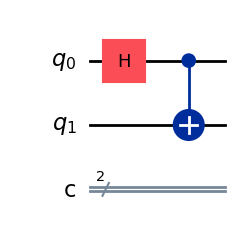


Measurement Results:
{'11': 503, '00': 521}


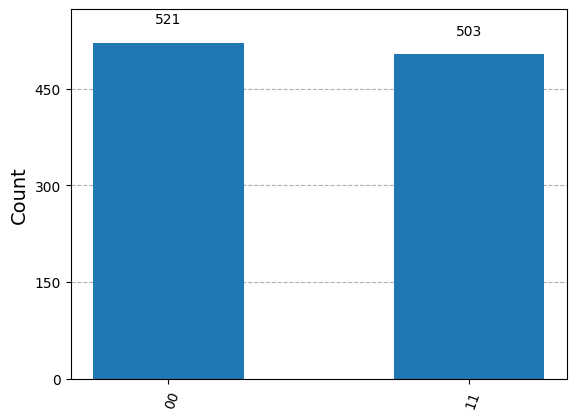

In [3]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from IPython.display import display

# Create a 2-qubit circuit
qc = QuantumCircuit(2, 2)

# Create Bell state
qc.h(0)
qc.cx(0, 1)

# Get statevector before measurement
state = Statevector.from_instruction(qc)

print("Bell State:")
print(state)

# Display circuit
display(qc.draw("mpl"))

# Measure both qubits
qc.measure([0, 1], [0, 1])

# Run 1024 shots
simulator = AerSimulator()
compiled = transpile(qc, simulator)
job = simulator.run(compiled, shots=1024)
result = job.result()

counts = result.get_counts()

print("\nMeasurement Results:")
print(counts)

# Display histogram
display(plot_histogram(counts))

## Observation

The Hadamard gate creates a superposition in the first qubit, and the CNOT gate creates entanglement between the two qubits. After 1024 measurements, the results are expected to contain only 00 and 11, with approximately equal frequencies.

## Conclusion

The Bell state was successfully created using the Hadamard and CNOT gates. The simulation verified that the two qubits are perfectly correlated, producing only the outcomes 00 and 11.

# Exercise 3 (Hard)

## Question

Implement a 3-qubit GHZ state and confirm perfect three-way correlation in the measurement results.

GHZ State:
Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.70710678+0.j],
            dims=(2, 2, 2))


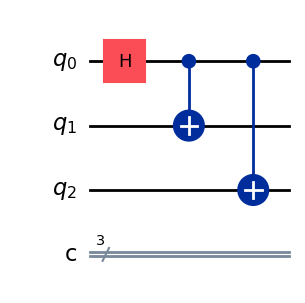


Measurement Results:
{'111': 521, '000': 503}


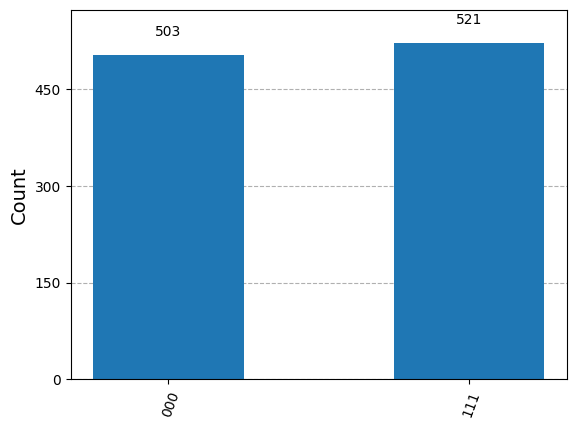

In [5]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from IPython.display import display

# Create a 3-qubit circuit
qc = QuantumCircuit(3, 3)

# Create GHZ state
qc.h(0)
qc.cx(0, 1)
qc.cx(0, 2)

# Get statevector before measurement
state = Statevector.from_instruction(qc)

print("GHZ State:")
print(state)

# Display circuit
display(qc.draw("mpl"))

# Measure all three qubits
qc.measure([0, 1, 2], [0, 1, 2])

# Run simulation
simulator = AerSimulator()
compiled = transpile(qc, simulator)
job = simulator.run(compiled, shots=1024)
result = job.result()

counts = result.get_counts()

print("\nMeasurement Results:")
print(counts)

# Display histogram
display(plot_histogram(counts))

## Observation

The Hadamard gate creates a superposition in the first qubit, and the two CNOT gates extend this state to all three qubits. The measurement results are expected to contain only 000 and 111, showing that all three qubits are perfectly correlated.

## Conclusion

The 3-qubit GHZ state was successfully created using one Hadamard gate and two CNOT gates. The simulation verified perfect three-way correlation because the qubits produced the same measurement value together.

# Exercise 4 (Real-World Application)

## Question

Emulate a classical full-adder circuit using Toffoli and CNOT gates.

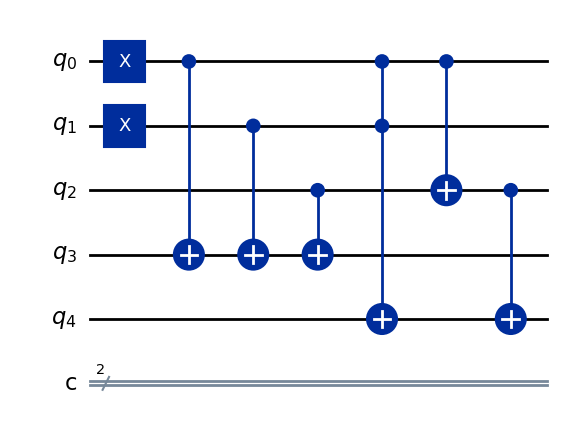

Measurement Results:
{'00': 1024}


In [7]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from IPython.display import display

# Full-adder inputs:
# q0 = A
# q1 = B
# q2 = Carry-in
# q3 = Sum
# q4 = Carry-out

qc = QuantumCircuit(5, 2)

# Example input: A = 1, B = 1, Cin = 0
qc.x(0)
qc.x(1)

# Sum = A XOR B XOR Cin
qc.cx(0, 3)
qc.cx(1, 3)
qc.cx(2, 3)

# Carry-out = AB XOR Cin(A XOR B)
qc.ccx(0, 1, 4)
qc.cx(0, 2)
qc.cx(2, 4)

# Display circuit
display(qc.draw("mpl"))

# Measure Sum and Carry-out
qc.measure(3, 0)
qc.measure(4, 1)

# Simulate
simulator = AerSimulator()
compiled = transpile(qc, simulator)
job = simulator.run(compiled, shots=1024)
result = job.result()

counts = result.get_counts()

print("Measurement Results:")
print(counts)

## Observation

The circuit uses CNOT gates to calculate the Sum and a Toffoli gate together with CNOT gates to calculate the Carry-out. For the input A = 1, B = 1 and Cin = 0, the expected Sum is 0 and the Carry-out is 1. Therefore, the full-adder produces the result Sum = 0 and Carry-out = 1.

## Conclusion

A classical full-adder was successfully emulated using quantum gates. The CNOT gates performed XOR operations for the Sum, while the Toffoli and CNOT gates generated the Carry-out. The simulation verified the expected full-adder result.

# Exercise 5 (Challenge)

## Question

Design a circuit producing a chosen arbitrary 2-qubit entangled state other than the standard Bell states and verify it via statevector inspection.

Arbitrary 2-Qubit Entangled State:
Statevector([0.82533561+0.j, 0.        +0.j, 0.        +0.j,
             0.56464247+0.j],
            dims=(2, 2))


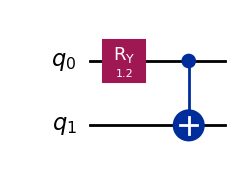

In [9]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from IPython.display import display

# Create a 2-qubit circuit
qc = QuantumCircuit(2)

# Create an arbitrary entangled state
qc.ry(1.2, 0)
qc.cx(0, 1)

# Get the final statevector
state = Statevector.from_instruction(qc)

print("Arbitrary 2-Qubit Entangled State:")
print(state)

# Display circuit
display(qc.draw("mpl"))

## Observation

The Ry gate creates a superposition with unequal amplitudes, and the CNOT gate entangles the two qubits. The resulting state is different from the standard Bell states because the amplitudes of |00⟩ and |11⟩ are not equal. The statevector confirms that the circuit produces an entangled 2-qubit state.

## Conclusion

An arbitrary 2-qubit entangled state was successfully created using an Ry gate followed by a CNOT gate. The statevector inspection verified that the resulting state is an entangled state and is different from the standard Bell states.

# Reflection Questions

### 1. How does entanglement differ from classical correlation?

Classical correlation means two objects have related values, but each object still has its own independent state. Quantum entanglement creates a shared quantum state where the qubits are strongly connected, and measuring one qubit affects what can be predicted about the other.

### 2. What practical difficulties did you face in scaling the circuit to 3 qubits?

As the number of qubits increases, the circuit becomes more complex and requires more gates and measurements. It also becomes harder to visualize and interpret the statevector and measurement results. Debugging the connections between multiple qubits can also become more difficult.